In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r'C:\Users\Administrator\Downloads\archive (2)\netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.shape

(8807, 12)

In [7]:
print(df['type'].value_counts())

Movie      6131
TV Show    2676
Name: type, dtype: int64


In [8]:
print(df['rating'].value_counts())

TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: rating, dtype: int64


In [9]:
print("Pldesr:", df['release_year'].min())

Pldesr: 1925


In [10]:
print("Newest:", df['release_year'].max)

Newest: <bound method NDFrame._add_numeric_operations.<locals>.max of 0       2020
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2007
8803    2018
8804    2009
8805    2006
8806    2015
Name: release_year, Length: 8807, dtype: int64>


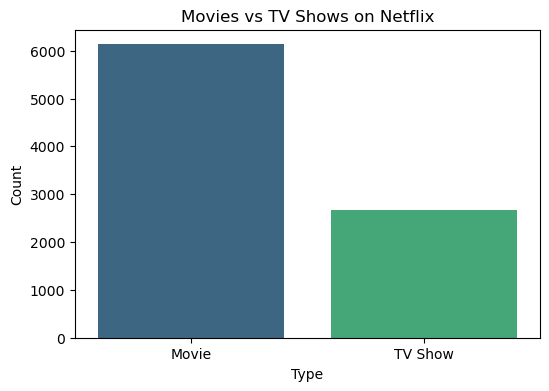

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

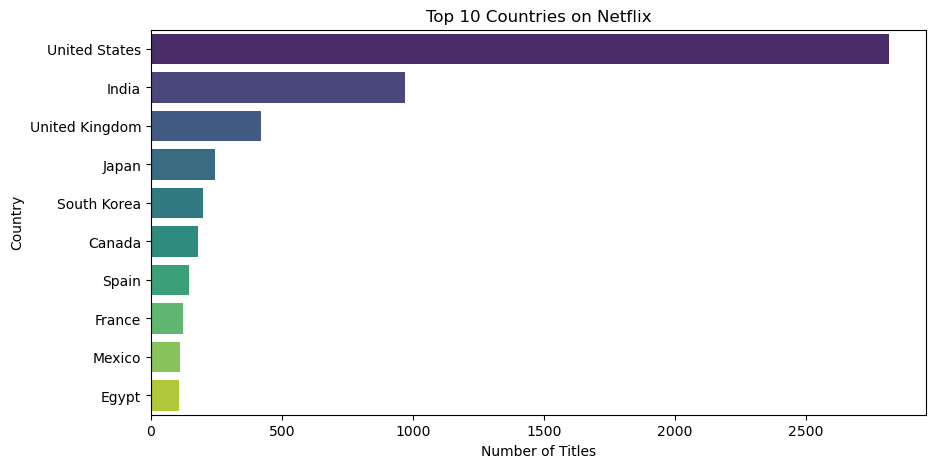

In [13]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_18984\1172375461.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=yearly.index, y=yearly.values, palette='viridis')


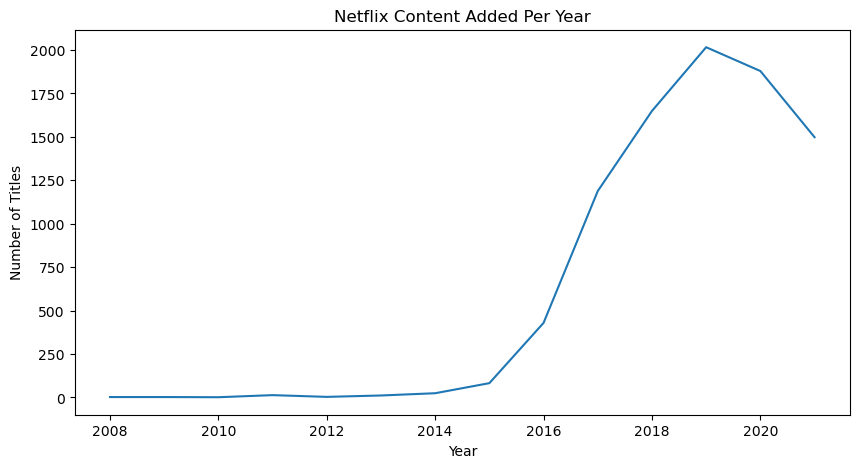

In [16]:
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
yearly = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly.index, y=yearly.values, palette='viridis')
plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

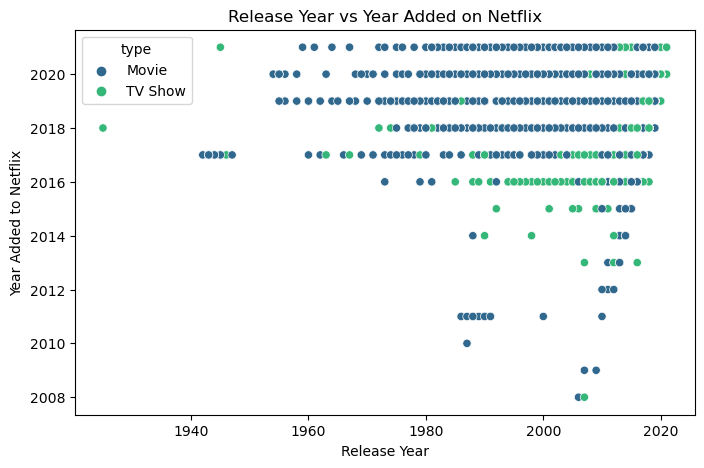

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='release_year', y='year_added', hue='type', palette='viridis')
plt.title('Release Year vs Year Added on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.show()

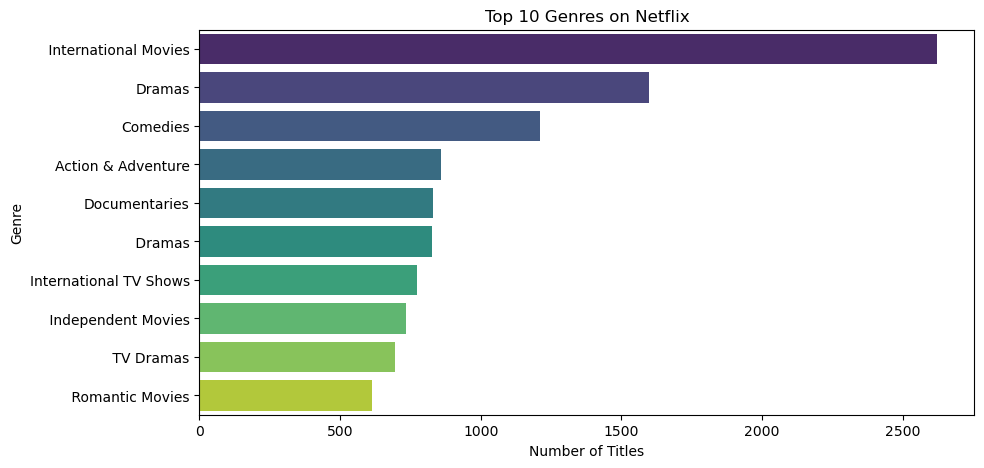

In [24]:
genres = df['listed_in'].str.split(',').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()